
[Loaded] /home/imagea/zhibo/DAPI_withUnet/phc_briancancer_multiscale_pooled_train_test.npz
keys: ['meta', 'train_files', 'train_labels', 'train_phc', 'test_files', 'test_labels', 'test_phc']
[use key] phc_train_files: train_files -> shape=(38544,)
[use key] phc_test_files: test_files -> shape=(4174,)
[use key] phc_train_labels: train_labels -> shape=(38544,)
[use key] phc_test_labels: test_labels -> shape=(4174,)
[use feature key] train_phc -> shape=(38544, 1200)
[use feature key] test_phc -> shape=(4174, 1200)

[Loaded] /home/imagea/zhibo/features_cache_briancancer_dinov3FD_fusion_RGB/dinov3FD_briancancer_train.npz
keys: ['feat', 'disc', 'indisc', 'logitsA', 'logitsB', 'y', 'paths', 'classes', 'encoder', 'ckpt', 'batch', 'best_epoch', 'refit', 'topo_npz_base', 'topo_c', 'topo_hw', 'topo_scheme']

[Loaded] /home/imagea/zhibo/features_cache_briancancer_dinov3FD_fusion_RGB/dinov3FD_briancancer_test.npz
keys: ['feat', 'disc', 'indisc', 'logitsA', 'logitsB', 'y', 'paths', 'classes', 'enco

/home/imagea/.conda/envs/unet2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/imagea/.conda/envs/unet2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



                             FINAL MULTI-METRIC RESULTS (BLOCK-L2 + ALPHA FUSION)                             
Split  Accuracy  Balanced Acc  Macro Precision  Macro Recall  Macro F1  Weighted Precision  Weighted Recall  Weighted F1
Train    0.9997        0.9997           0.9979        0.9997    0.9988              0.9997           0.9997       0.9997
 Test    0.9859        0.9633           0.9750        0.9633    0.9679              0.9870           0.9859       0.9858

Classification Report (Test):
              precision    recall  f1-score   support

       astro     0.9027    0.9978    0.9479       465
         gbm     1.0000    1.0000    1.0000       241
       necro     0.9767    0.9333    0.9545        90
      normal     0.9980    0.9990    0.9985      2947
       oligo     0.9974    0.8863    0.9386       431

    accuracy                         0.9859      4174
   macro avg     0.9750    0.9633    0.9679      4174
weighted avg     0.9870    0.9859    0.9858      4174


Save

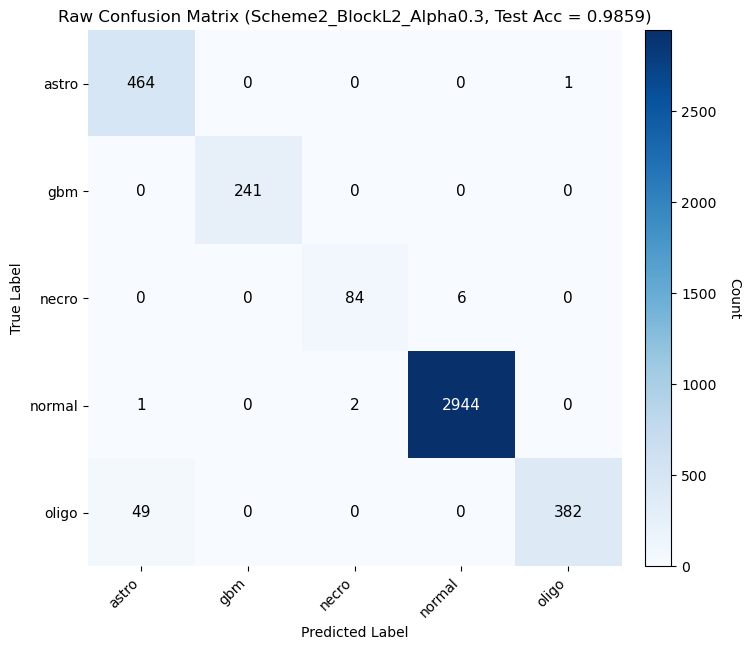

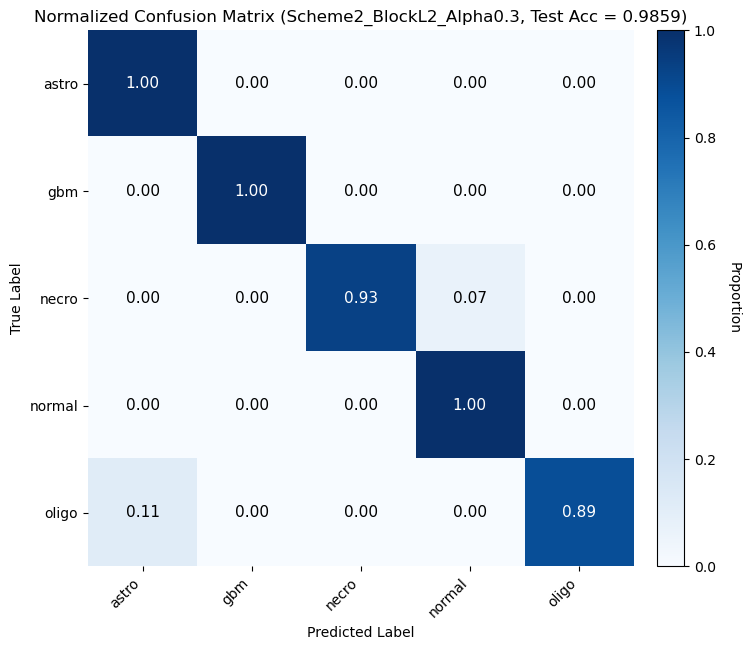


All outputs saved to: ./late_fusion_scheme2_block_l2_alpha
Also saved:
 - ./late_fusion_scheme2_block_l2_alpha/final_metrics_summary_Scheme2_BlockL2_Alpha0.3.csv
 - ./late_fusion_scheme2_block_l2_alpha/coef_block_summary_Scheme2_BlockL2_Alpha0.3.csv
 - ./late_fusion_scheme2_block_l2_alpha/confusion_matrix_raw_Scheme2_BlockL2_Alpha0.3.png
 - ./late_fusion_scheme2_block_l2_alpha/confusion_matrix_raw_Scheme2_BlockL2_Alpha0.3.pdf
 - ./late_fusion_scheme2_block_l2_alpha/confusion_matrix_normalized_Scheme2_BlockL2_Alpha0.3.png
 - ./late_fusion_scheme2_block_l2_alpha/confusion_matrix_normalized_Scheme2_BlockL2_Alpha0.3.pdf


In [ ]:


import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

PHC_PATH = "/path/to/your/phc_briancancer_multiscale_pooled_train_test.npz"
DINO_TRAIN_PATH = "/path/to/your/features_cache_briancancer_dinov3FD_fusion_RGB/dinov3FD_briancancer_train.npz"
DINO_TEST_PATH  = "/path/to/your/features_cache_briancancer_dinov3FD_fusion_RGB/dinov3FD_briancancer_test.npz"
SAVE_DIR = "./late_fusion_scheme2_block_l2_alpha"
os.makedirs(SAVE_DIR, exist_ok=True)


def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

def _safe_npz_load(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"file can not be found: {path}")
    x = np.load(path, allow_pickle=True)
    print(f"\n[Loaded] {path}")
    print("keys:", list(x.files))
    return x

def _norm_path_str(x):
    x = str(x)
    x = x.replace("\\", "/")
    return os.path.normpath(x).replace("\\", "/")

def _basename_noext(x):
    return os.path.splitext(os.path.basename(_norm_path_str(x)))[0]

def _parent_and_base(x):
    x = _norm_path_str(x)
    parent = os.path.basename(os.path.dirname(x))
    base = _basename_noext(x)
    return f"{parent}/{base}"

def _canonical_keys_from_path(x):
    x = _norm_path_str(x)
    base = _basename_noext(x)
    parent_base = _parent_and_base(x)

    ks = {x, os.path.basename(x), base, parent_base}

    weak = re.sub(r"(_x\d+_y\d+)$", "", base)
    weak = re.sub(r"(_patch\d+)$", "", weak)
    weak = re.sub(r"(_aug\d+)$", "", weak)
    weak = re.sub(r"(_tile\d+)$", "", weak)
    weak = re.sub(r"(_crop\d+)$", "", weak)
    ks.add(weak)

    return [k for k in ks if isinstance(k, str) and len(k) > 0]

def _pick_first_existing(npz_obj, candidates, required=False, name=""):
    for k in candidates:
        if k in npz_obj.files:
            arr = npz_obj[k]
            print(f"[use key] {name}: {k} -> shape={getattr(arr, 'shape', None)}")
            return arr, k
    if required:
        raise KeyError(f"Cannot find {name}. Available keys = {candidates}")
    return None, None

def _find_feature_array(npz_obj, prefer_names):
    for k in prefer_names:
        if k in npz_obj.files:
            arr = np.asarray(npz_obj[k])
            if arr.ndim >= 2:
                print(f"[use feature key] {k} -> shape={arr.shape}")
                return arr, k

    best_k, best_arr = None, None
    for k in npz_obj.files:
        arr = np.asarray(npz_obj[k])
        if arr.ndim >= 2 and arr.shape[0] >= 10:
            best_k, best_arr = k, arr
            break

    if best_arr is None:
        raise KeyError("Cannot find feature array in npz")
    print(f"[fallback feature key] {best_k} -> shape={best_arr.shape}")
    return best_arr, best_k

def _flatten_feat(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 1:
        x = x[:, None]
    elif x.ndim > 2:
        x = x.reshape(x.shape[0], -1)
    return x.astype(np.float32)

def _build_index_from_paths(paths):
    index = {}
    for i, p in enumerate(paths):
        for k in _canonical_keys_from_path(p):
            if k not in index:
                index[k] = i
    return index

def _align_by_paths(ref_paths, ref_labels, ref_feat, qry_paths, qry_feat, split_name="train"):
    qry_index = _build_index_from_paths(qry_paths)
    keep_ref_idx, keep_qry_idx, miss = [], [], []

    for i, p in enumerate(ref_paths):
        matched = None
        for k in _canonical_keys_from_path(p):
            if k in qry_index:
                matched = qry_index[k]
                break
        if matched is None:
            miss.append(p)
        else:
            keep_ref_idx.append(i)
            keep_qry_idx.append(matched)

    keep_ref_idx = np.asarray(keep_ref_idx, dtype=np.int64)
    keep_qry_idx = np.asarray(keep_qry_idx, dtype=np.int64)

    print(f"\n[{split_name}] align matched: {len(keep_ref_idx)} / {len(ref_paths)}")
    print(f"[{split_name}] unmatched    : {len(miss)}")
    if len(miss) > 0:
        print(f"[{split_name}] first 10 unmatched examples:")
        for x in miss[:10]:
            print("  -", x)

    if len(keep_ref_idx) == 0:
        raise RuntimeError(f"{split_name} None of them are aligned properly. Please check the path key.")

    out_paths = np.asarray(ref_paths)[keep_ref_idx]
    out_labels = np.asarray(ref_labels)[keep_ref_idx]
    out_ref_feat = np.asarray(ref_feat)[keep_ref_idx]
    out_qry_feat = np.asarray(qry_feat)[keep_qry_idx]
    return out_paths, out_labels, out_ref_feat, out_qry_feat

def _coerce_split_lengths(split_name, files, labels, feat):
    n_files = len(files)
    n_labels = len(labels)
    n_feat = int(getattr(feat, "shape", [0])[0])
    n = int(min(n_files, n_labels, n_feat))

    if not (n_files == n_labels == n_feat):
        print(f"[WARN] {split_name}: length mismatch files={n_files} labels={n_labels} feat={n_feat}; trim to {n}")

    if n <= 0:
        raise RuntimeError(f"{split_name}: No samples available")
    return files[:n], labels[:n], feat[:n]

def l2_norm_rows(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float32)
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    return x / (norm + eps)

phc_npz = _safe_npz_load(PHC_PATH)

phc_train_files, _ = _pick_first_existing(
    phc_npz,
    ["train_files", "files_train", "train_paths", "paths_train"],
    required=True,
    name="phc_train_files",
)
phc_test_files, _ = _pick_first_existing(
    phc_npz,
    ["test_files", "files_test", "test_paths", "paths_test"],
    required=True,
    name="phc_test_files",
)

phc_train_labels, _ = _pick_first_existing(
    phc_npz,
    ["train_labels", "labels_train", "y_train_str"],
    required=True,
    name="phc_train_labels",
)
phc_test_labels, _ = _pick_first_existing(
    phc_npz,
    ["test_labels", "labels_test", "y_test_str"],
    required=True,
    name="phc_test_labels",
)

phc_train_feat, _ = _find_feature_array(
    phc_npz,
    ["train_phc", "phc_train", "X_train", "train_features", "features_train"],
)
phc_test_feat, _ = _find_feature_array(
    phc_npz,
    ["test_phc", "phc_test", "X_test", "test_features", "features_test"],
)

phc_train_files = np.asarray(phc_train_files, dtype=str)
phc_test_files  = np.asarray(phc_test_files, dtype=str)
phc_train_labels = np.asarray(phc_train_labels, dtype=str)
phc_test_labels  = np.asarray(phc_test_labels, dtype=str)
phc_train_feat = _flatten_feat(phc_train_feat)
phc_test_feat  = _flatten_feat(phc_test_feat)

phc_train_files, phc_train_labels, phc_train_feat = _coerce_split_lengths(
    "phc_train", phc_train_files, phc_train_labels, phc_train_feat
)
phc_test_files, phc_test_labels, phc_test_feat = _coerce_split_lengths(
    "phc_test", phc_test_files, phc_test_labels, phc_test_feat
)


dino_train_npz = _safe_npz_load(DINO_TRAIN_PATH)
dino_test_npz  = _safe_npz_load(DINO_TEST_PATH)

dino_train_files, _ = _pick_first_existing(
    dino_train_npz,
    ["files", "train_files", "img_paths", "paths", "patch_files", "src_img", "image_paths", "filenames"],
    required=True,
    name="dino_train_files",
)
dino_test_files, _ = _pick_first_existing(
    dino_test_npz,
    ["files", "test_files", "img_paths", "paths", "patch_files", "src_img", "image_paths", "filenames"],
    required=True,
    name="dino_test_files",
)

dino_train_feat, _ = _find_feature_array(
    dino_train_npz,
    ["features", "feats", "x", "embeddings", "cls_feats", "train_features"],
)
dino_test_feat, _ = _find_feature_array(
    dino_test_npz,
    ["features", "feats", "x", "embeddings", "cls_feats", "test_features"],
)

dino_train_files = np.asarray(dino_train_files, dtype=str)
dino_test_files  = np.asarray(dino_test_files, dtype=str)
dino_train_feat  = _flatten_feat(dino_train_feat)
dino_test_feat   = _flatten_feat(dino_test_feat)

assert len(dino_train_files) == dino_train_feat.shape[0]
assert len(dino_test_files)  == dino_test_feat.shape[0]

train_files, train_labels, X_phc_train, X_dino_train = _align_by_paths(
    ref_paths=phc_train_files,
    ref_labels=phc_train_labels,
    ref_feat=phc_train_feat,
    qry_paths=dino_train_files,
    qry_feat=dino_train_feat,
    split_name="train",
)

test_files, test_labels, X_phc_test, X_dino_test = _align_by_paths(
    ref_paths=phc_test_files,
    ref_labels=phc_test_labels,
    ref_feat=phc_test_feat,
    qry_paths=dino_test_files,
    qry_feat=dino_test_feat,
    split_name="test",
)

print("\nFinal aligned shapes:")
print("train_files :", train_files.shape)
print("train_labels:", train_labels.shape)
print("X_phc_train :", X_phc_train.shape)
print("X_dino_train:", X_dino_train.shape)
print("test_files  :", test_files.shape)
print("test_labels :", test_labels.shape)
print("X_phc_test  :", X_phc_test.shape)
print("X_dino_test :", X_dino_test.shape)


ALL_DOMAINS = sorted(set(train_labels.tolist()))
domain_to_id = {d: i for i, d in enumerate(ALL_DOMAINS)}
id_to_domain = {i: d for d, i in domain_to_id.items()}
class_names = [id_to_domain[i] for i in range(len(id_to_domain))]

y_train = np.asarray([domain_to_id[str(x)] for x in train_labels], dtype=np.int64)

unknown = sorted(set(test_labels.tolist()) - set(ALL_DOMAINS))
if len(unknown) > 0:
    raise AssertionError(f"Test set contains unseen classes: {unknown}")
y_test = np.asarray([domain_to_id[str(x)] for x in test_labels], dtype=np.int64)

print("\nclasses:", domain_to_id)
print("Train class distribution:", Counter(y_train.tolist()))
print("Test  class distribution:", Counter(y_test.tolist()))


# ---- DINO: Z-score ----
dino_mean = X_dino_train.mean(axis=0, keepdims=True).astype(np.float32)
dino_std  = (X_dino_train.std(axis=0, keepdims=True) + 1e-6).astype(np.float32)

X_dino_train_n = (X_dino_train - dino_mean) / dino_std
X_dino_test_n  = (X_dino_test  - dino_mean) / dino_std

# ---- PHC: MinMax ----
phc_min = X_phc_train.min(axis=0, keepdims=True).astype(np.float32)
phc_max = X_phc_train.max(axis=0, keepdims=True).astype(np.float32)
phc_range = np.where((phc_max - phc_min) == 0, 1e-6, phc_max - phc_min)

X_phc_train_n = (X_phc_train - phc_min) / phc_range
X_phc_test_n  = (X_phc_test  - phc_min) / phc_range

print("\nAfter base normalization:")
print(f"DINO train shape: {X_dino_train_n.shape}, range: [{X_dino_train_n.min():.4f}, {X_dino_train_n.max():.4f}]")
print(f"PHC  train shape: {X_phc_train_n.shape}, range: [{X_phc_train_n.min():.4f}, {X_phc_train_n.max():.4f}]")


# Block-level L2 normalize + alpha weighted fusion

ALPHA = 0.3   

X_dino_train_b = l2_norm_rows(X_dino_train_n)
X_dino_test_b  = l2_norm_rows(X_dino_test_n)

X_phc_train_b = l2_norm_rows(X_phc_train_n)
X_phc_test_b  = l2_norm_rows(X_phc_test_n)

X_train = np.concatenate([X_dino_train_b, ALPHA * X_phc_train_b], axis=1).astype(np.float32)
X_test  = np.concatenate([X_dino_test_b,  ALPHA * X_phc_test_b], axis=1).astype(np.float32)

print("\nAfter block-level L2 + fusion:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print(f"ALPHA  : {ALPHA}")


# Logistic Regression 

print("\n--- Training Logistic Regression ---")
clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

clf.fit(X_train, y_train)

y_pred_train = clf.predict(X_train)
y_pred_test  = clf.predict(X_test)

tag = f"Scheme2_BlockL2_Alpha{ALPHA}"

def build_metric_dict(split_name, y_true, y_pred):
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "Split": split_name,
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced Acc": float(balanced_accuracy_score(y_true, y_pred)),
        "Macro Precision": float(p_m),
        "Macro Recall": float(r_m),
        "Macro F1": float(f1_m),
        "Weighted Precision": float(p_w),
        "Weighted Recall": float(r_w),
        "Weighted F1": float(f1_w),
    }


train_metrics = build_metric_dict("Train", y_train, y_pred_train)
test_metrics  = build_metric_dict("Test",  y_test,  y_pred_test)
metrics_df = pd.DataFrame([train_metrics, test_metrics])

print("\n" + "=" * 110)
print(f"{'FINAL MULTI-METRIC RESULTS (BLOCK-L2 + ALPHA FUSION)':^110}")
print("=" * 110)
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 110)

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test, target_names=class_names, digits=4))

metrics_csv_path = os.path.join(SAVE_DIR, f"final_metrics_summary_{tag}.csv")
metrics_df.to_csv(metrics_csv_path, index=False, encoding="utf-8-sig")
print(f"\nSaved metrics csv: {metrics_csv_path}")


coef = clf.coef_   # shape: [n_classes, total_dim]
dino_dim = X_dino_train_b.shape[1]

coef_dino = coef[:, :dino_dim]
coef_phc  = coef[:, dino_dim:]

coef_summary = pd.DataFrame({
    "Block": ["DINO", "PHC"],
    "MeanAbsCoef": [
        float(np.mean(np.abs(coef_dino))),
        float(np.mean(np.abs(coef_phc))),
    ],
    "StdAbsCoef": [
        float(np.std(np.abs(coef_dino))),
        float(np.std(np.abs(coef_phc))),
    ],
    "MaxAbsCoef": [
        float(np.max(np.abs(coef_dino))),
        float(np.max(np.abs(coef_phc))),
    ],
})

coef_csv_path = os.path.join(SAVE_DIR, f"coef_block_summary_{tag}.csv")
coef_summary.to_csv(coef_csv_path, index=False, encoding="utf-8-sig")

print("\nCoefficient block summary:")
print(coef_summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print(f"Saved coef summary: {coef_csv_path}")


# confusion matrix plot

def plot_confusion_matrix_paper(cm_in, cnames, title, save_png, save_pdf=None, normalize=False):
    fig, ax = plt.subplots(figsize=(7.6, 6.6))
    im = ax.imshow(cm_in, interpolation="nearest", cmap="Blues", aspect="auto")

    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proportion" if normalize else "Count", rotation=270, labelpad=18)

    ax.set_xticks(np.arange(len(cnames)))
    ax.set_yticks(np.arange(len(cnames)))
    ax.set_xticklabels(cnames, rotation=45, ha="right")
    ax.set_yticklabels(cnames)

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(title)

    thresh = cm_in.max() / 2.0 if cm_in.size > 0 else 0.0
    for i in range(cm_in.shape[0]):
        for j in range(cm_in.shape[1]):
            txt = f"{cm_in[i, j]:.2f}" if normalize else f"{int(cm_in[i, j])}"
            ax.text(
                j, i, txt,
                ha="center", va="center",
                color="white" if cm_in[i, j] > thresh else "black",
                fontsize=11,
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlim(-0.5, len(cnames) - 0.5)
    ax.set_ylim(len(cnames) - 0.5, -0.5)

    plt.tight_layout()
    plt.savefig(save_png, bbox_inches="tight")
    if save_pdf is not None:
        plt.savefig(save_pdf, bbox_inches="tight")
    plt.show()
    plt.close(fig)

cm = confusion_matrix(y_test, y_pred_test)
cm_norm = confusion_matrix(y_test, y_pred_test, normalize="true")

cm_png = os.path.join(SAVE_DIR, f"confusion_matrix_raw_{tag}.png")
cm_pdf = os.path.join(SAVE_DIR, f"confusion_matrix_raw_{tag}.pdf")
cmn_png = os.path.join(SAVE_DIR, f"confusion_matrix_normalized_{tag}.png")
cmn_pdf = os.path.join(SAVE_DIR, f"confusion_matrix_normalized_{tag}.pdf")

plot_confusion_matrix_paper(
    cm,
    class_names,
    f"Raw Confusion Matrix ({tag}, Test Acc = {test_metrics['Accuracy']:.4f})",
    cm_png,
    cm_pdf,
    normalize=False,
)

plot_confusion_matrix_paper(
    cm_norm,
    class_names,
    f"Normalized Confusion Matrix ({tag}, Test Acc = {test_metrics['Accuracy']:.4f})",
    cmn_png,
    cmn_pdf,
    normalize=True,
)

print(f"\nAll outputs saved to: {SAVE_DIR}")
print("Also saved:")
print(" -", metrics_csv_path)
print(" -", coef_csv_path)
print(" -", cm_png)
print(" -", cm_pdf)
print(" -", cmn_png)
print(" -", cmn_pdf)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4174 samples in 0.001s...
[t-SNE] Computed neighbors for 4174 samples in 0.255s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4174
[t-SNE] Computed conditional probabilities for sample 2000 / 4174
[t-SNE] Computed conditional probabilities for sample 3000 / 4174
[t-SNE] Computed conditional probabilities for sample 4000 / 4174
[t-SNE] Computed conditional probabilities for sample 4174 / 4174
[t-SNE] Mean sigma: 0.151358
[t-SNE] KL divergence after 250 iterations with early exaggeration: 72.354568
[t-SNE] KL divergence after 2000 iterations: 1.228374


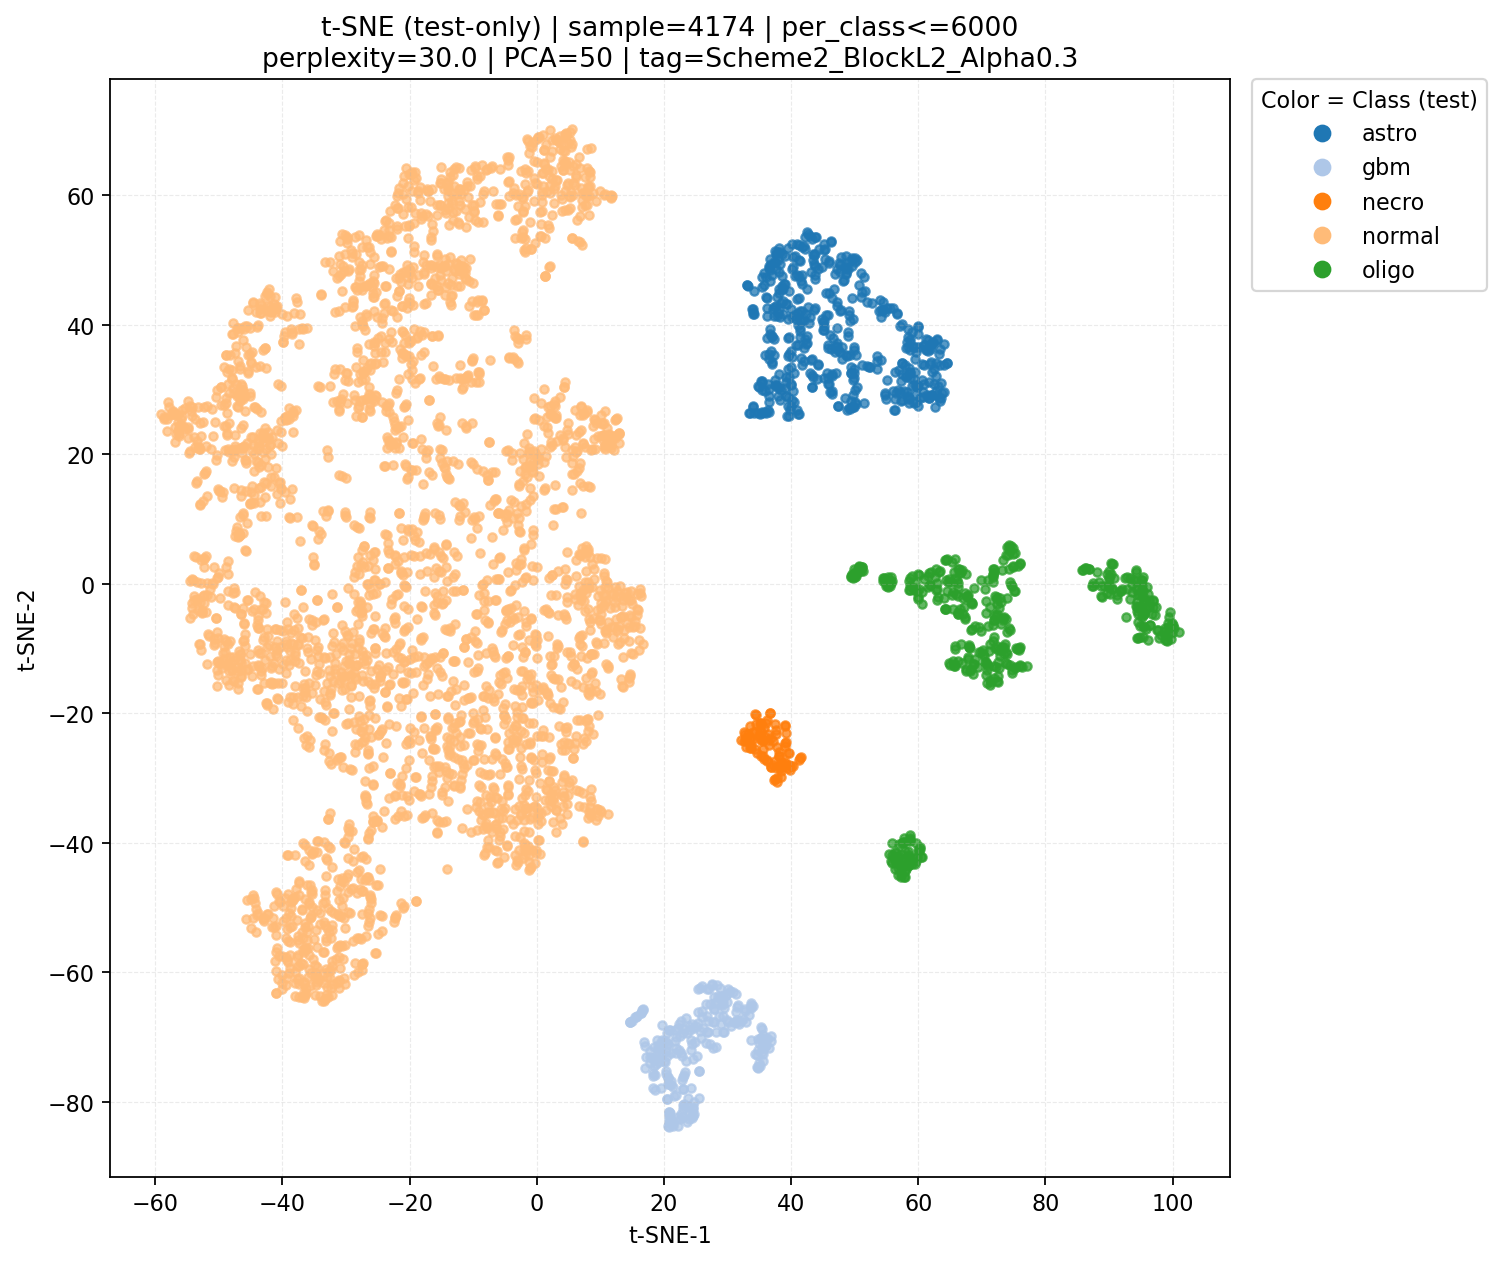

[tsne] saved: ./late_fusion_scheme2_block_l2_alpha/tsne_testonly_perclass6000_Scheme2_BlockL2_Alpha0.3.png


In [ ]:

# t-SNE

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D


TSNE_SAMPLES_PER_CLASS = 6000
TSNE_SEED = 0
TSNE_PCA_DIM = 50
TSNE_PERPLEXITY = 30.0
TSNE_MAX_ITER = 2000

# ---------- only test ----------
X_all = np.asarray(X_test, dtype=np.float32)
y_all = np.asarray(y_test, dtype=np.int64)

per_class = int(max(1, TSNE_SAMPLES_PER_CLASS))
rng = np.random.default_rng(int(TSNE_SEED))

sel_list = []
for cid in range(len(class_names)):
    idx = np.flatnonzero(y_all == cid)
    if idx.size == 0:
        continue
    if idx.size > per_class:
        idx = rng.choice(idx, size=per_class, replace=False)
    sel_list.append(np.asarray(idx, dtype=np.int64))

if len(sel_list) == 0:
    raise RuntimeError("t-SNE sampling is empty: Please check y_test/class_names")

sel = np.unique(np.concatenate(sel_list, axis=0))
X_use = X_all[sel]
y_use = y_all[sel]

# ---------- PCA -> t-SNE ----------
pca_dim = int(max(2, min(int(TSNE_PCA_DIM), X_use.shape[1])))
X_pca = PCA(n_components=pca_dim, random_state=int(TSNE_SEED)).fit_transform(X_use)

perplexity = float(TSNE_PERPLEXITY)
perplexity = max(5.0, min(perplexity, (X_pca.shape[0] - 1) / 3.0))

tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=perplexity,
    max_iter=int(TSNE_MAX_ITER),
    random_state=int(TSNE_SEED),
    verbose=1,
)
Z = tsne.fit_transform(X_pca)

fig, ax = plt.subplots(figsize=(9.5, 8.0), dpi=160)

n_cls = int(len(class_names))
try:
    cmap = plt.colormaps.get_cmap("tab20")
except Exception:
    cmap = plt.cm.get_cmap("tab20")
colors = [cmap(i % 20) for i in range(n_cls)]

present_cids = []
for cid in range(n_cls):
    m = (y_use == cid)
    if not np.any(m):
        continue
    present_cids.append(cid)
    ax.scatter(Z[m, 0], Z[m, 1], s=14, c=[colors[cid]], marker="o", alpha=0.75)

ax.set_title(
    f"t-SNE (test-only) | sample={Z.shape[0]} | per_class<={per_class}\n"
    f"perplexity={perplexity:.1f} | PCA={pca_dim} | tag={tag}"
)
ax.set_xlabel("t-SNE-1")
ax.set_ylabel("t-SNE-2")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.25)

handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=str(class_names[cid]),
        markerfacecolor=colors[cid],
        markeredgecolor=colors[cid],
        markersize=7,
        linestyle="None",
    )
    for cid in present_cids
]
ax.legend(
    handles=handles,
    title="Color = Class (test)",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True,
)

os.makedirs(SAVE_DIR, exist_ok=True)
out_png = os.path.join(SAVE_DIR, f"tsne_testonly_perclass{per_class}_{tag}.png")
fig.tight_layout()
fig.savefig(out_png, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

print("[tsne] saved:", out_png)